# Student Performance Prediction
### Linear Regression — Intern Assignment

This project builds a machine learning model to predict a student's exam score
based on their study habits and lifestyle factors.

**Input Features:**
- Hours Studied
- Previous Scores
- Extracurricular Activities
- Sleep Hours
- Sample Question Papers Practiced

**Output:**
- Performance Index (Predicted Exam Score)

## 1. Importing Libraries

We import all the necessary libraries needed for this project.

- **pandas** — to load and work with the dataset
- **numpy** — for numerical calculations like RMSE
- **matplotlib & seaborn** — to create visualizations and plots
- **scikit-learn** — to build and evaluate the Linear Regression model
- **joblib** — to save the trained model to a file

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import joblib

## 2. Loading the Dataset

We load the Student Performance dataset from a CSV file using pandas.

The dataset contains **10,000 student records** with 6 columns:
- 5 input features
- 1 output variable (Performance Index)

After loading we check:
- Shape of the dataset (rows and columns)
- First few rows to confirm it loaded correctly
- Data types of each column
- Missing values
- Duplicate rows
- Basic statistics using describe()

In [5]:
df = pd.read_csv("Student_Performance.csv")

In [6]:
print("Shape of df",df.shape)

Shape of df (10000, 6)


In [7]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


## 3. Preprocessing & Encoding

Before training the model we need to prepare the data.

**Steps:**
1. Check for missing values — ensure no empty cells exist
2. Encode categorical variable — Extracurricular Activities is Yes/No
   which needs to be converted to 1/0 for the model to understand
3. Select 5 input features (X) and 1 output variable (y)
4. Split data into 80% training and 20% testing sets

Machine learning models only work with numbers,
so text values like Yes and No must be converted first.

In [10]:
df.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [11]:
df.duplicated().sum()

127

In [12]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [13]:
df["Hours Studied"].unique()

array([7, 4, 8, 5, 3, 6, 2, 1, 9], dtype=int64)

In [14]:
df["Sleep Hours"].unique()

array([9, 4, 7, 5, 8, 6], dtype=int64)

In [15]:
df.describe(include = object)

,Extracurricular Activities
count,10000
unique,2
top,No
freq,5052


In [16]:
df['Extracurricular Activities'].head()

0    Yes
1     No
2    Yes
3    Yes
4     No
Name: Extracurricular Activities, dtype: object

In [17]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
print("Unique values after encoding:", df['Extracurricular Activities'].unique())

Unique values after encoding: [1 0]


In [18]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [19]:
# Check skewness of all numeric columns
print("Skewness of each feature:")
print(df.skew())

Skewness of each feature:
Hours Studied                      -0.004213
Previous Scores                     0.004502
Extracurricular Activities          0.020804
Sleep Hours                        -0.039474
Sample Question Papers Practiced   -0.035636
Performance Index                  -0.001740
dtype: float64


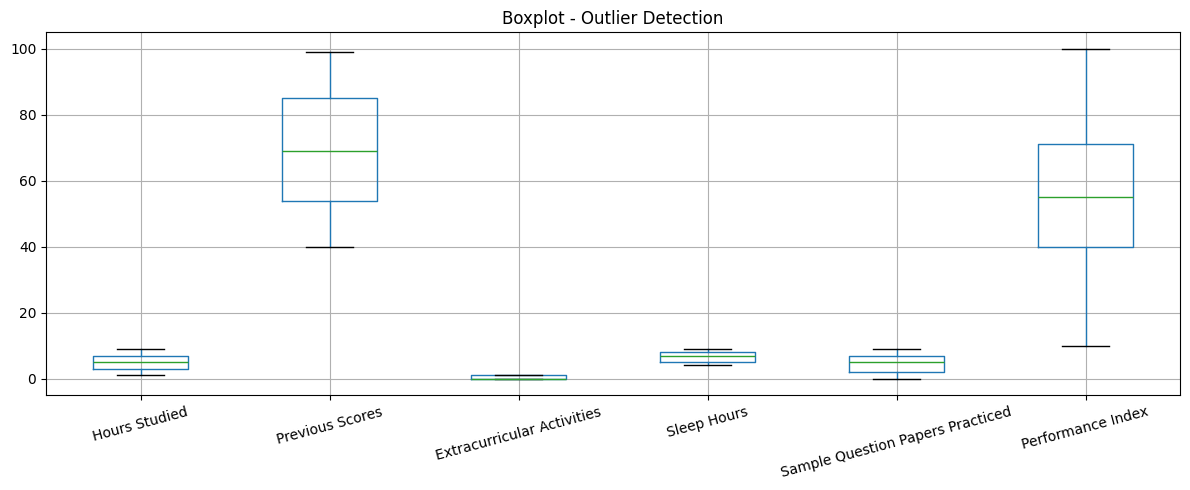

In [20]:
plt.figure(figsize=(12, 5))
df.boxplot(figsize=(12, 5))
plt.title("Boxplot - Outlier Detection")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [21]:
# Select input features 
X = df[['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 
        'Sleep Hours', 'Sample Question Papers Practiced']]
y = df['Performance Index']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirm the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 5)
X_test shape: (2000, 5)
y_train shape: (8000,)
y_test shape: (2000,)


## 4. Correlation Analysis

Correlation tells us how strongly each input feature is related to the output (Performance Index).

- A value close to **1** means strong positive relationship
- A value close to **0** means no relationship
- A value close to **-1** means strong negative relationship

We use a heatmap to visualize this so it is easy to read.

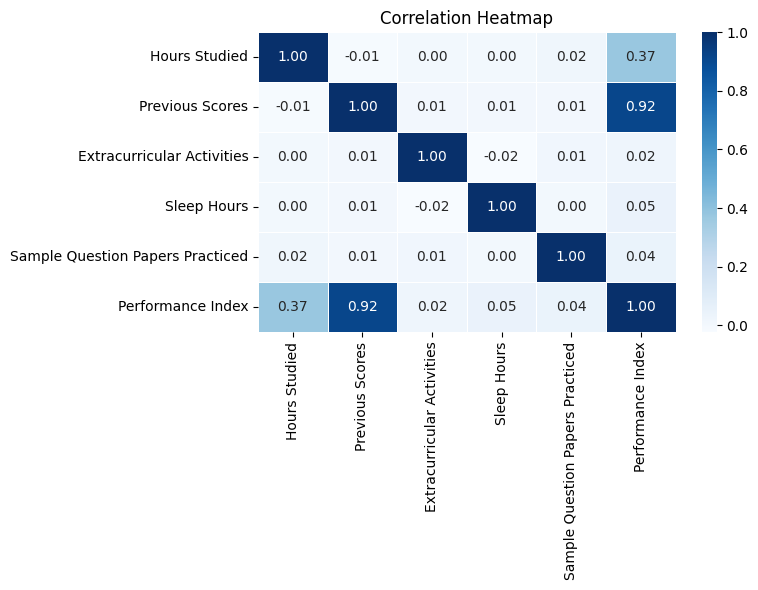

In [23]:
# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Correlation Analysis Observations

- Previous Scores has the strongest correlation (0.92) with Performance Index
- Hours Studied has a moderate correlation (0.37) with Performance Index
- Sleep Hours, Sample Question Papers, and Extracurricular Activities 
  have very weak correlations (< 0.05)
- No multicollinearity detected between input features (all < 0.05)
- All 5 features are kept as no redundancy exists between them

## 5. Model Training

We use **Linear Regression** to build our prediction model.

Linear Regression finds the best straight line that fits the data
by learning the relationship between input features and the output score.

- We train the model using 80% of the data (training set)
- The remaining 20% is kept aside for testing (test set)
- The model learns coefficients (weights) for each feature

In [26]:
# Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

## 6. Model Evaluation

After training, we check how well the model performs on unseen test data.

We use 4 standard metrics:

| Metric | What it measures |
|--------|-----------------|
| MAE  | Average error in score points |
| MSE  | Penalizes larger errors more |
| RMSE | Error in same unit as the score |
| R²   | How much variance the model explains (closer to 1 is better) |

In [28]:
# Model Evaluation metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

In [29]:
print(f"  MAE  (Mean Absolute Error)  : {mae:.4f}")
print(f"  MSE  (Mean Squared Error)   : {mse:.4f}")
print(f"  RMSE (Root Mean Sq. Error)  : {rmse:.4f}")
print(f"  R²   (R-Squared Score)      : {r2:.4f}")

  MAE  (Mean Absolute Error)  : 1.6111
  MSE  (Mean Squared Error)   : 4.0826
  RMSE (Root Mean Sq. Error)  : 2.0206
  R²   (R-Squared Score)      : 0.9890


## Model Evaluation Observations

- R² Score of 0.989 means the model explains 98.9% of variance in exam scores
- MAE of 1.61 means average prediction error is only 1.6 marks out of 100
- RMSE of 2.02 confirms predictions are consistently close to actual values
- The model performs excellently — Previous Scores being highly 
  correlated (0.92) is the main reason for this strong performance

## Hyperparameter Tuning

Linear Regression uses Ordinary Least Squares (OLS) to mathematically 
compute the best coefficients — it has no hyperparameters to tune.

If performance were poor, alternatives would be:
- Ridge Regression (L2 regularization) — controls overfitting
- Lasso Regression (L1 regularization) — also does feature selection

Since R² = 0.989, the base Linear Regression model is sufficient.

## 7. Visualizations

We create 3 plots to better understand the model results:

1. **Actual vs Predicted Plot**
   - Shows how close predictions are to real scores
   - Dots should fall near the red diagonal line

2. **Residuals Plot**
   - Residual = Actual Score - Predicted Score
   - Dots should be randomly scattered around 0
   - Any pattern here means the model is missing something

3. **Feature Coefficients Plot**
   - Shows which features impact the score the most
   - Longer bar = more influence on the predicted score

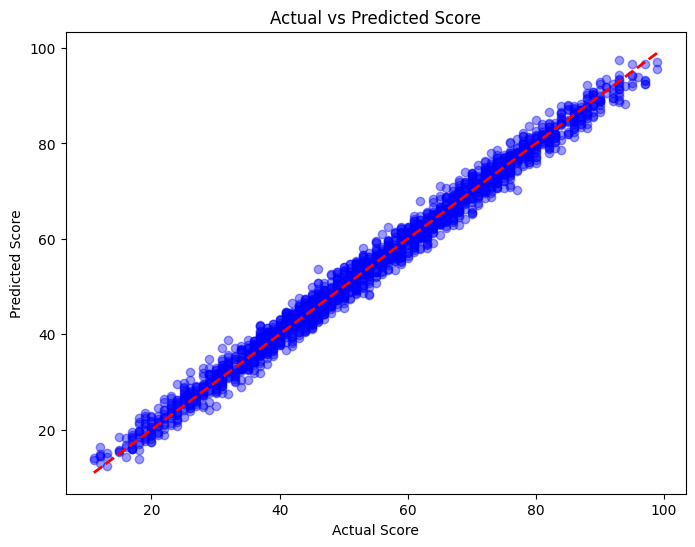

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color='blue', alpha=0.4)

plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linewidth=2, linestyle='--')

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Score")

plt.show()

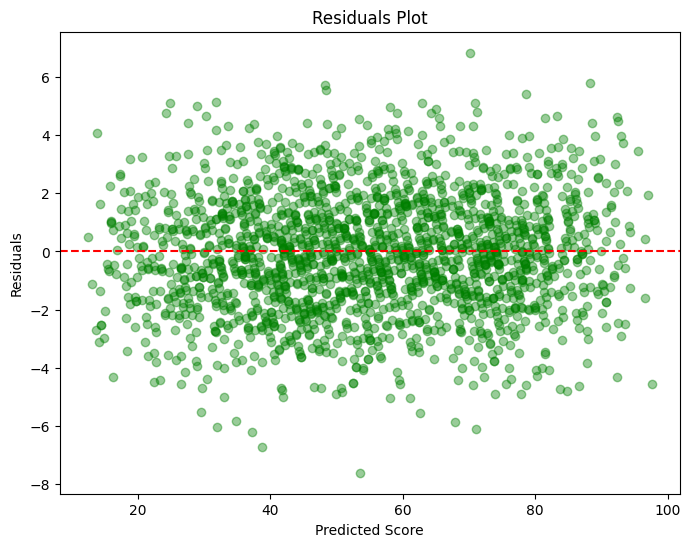

In [34]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, color='green', alpha=0.4)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Score")
plt.ylabel("Residuals")
plt.title("Residuals Plot")

plt.show()

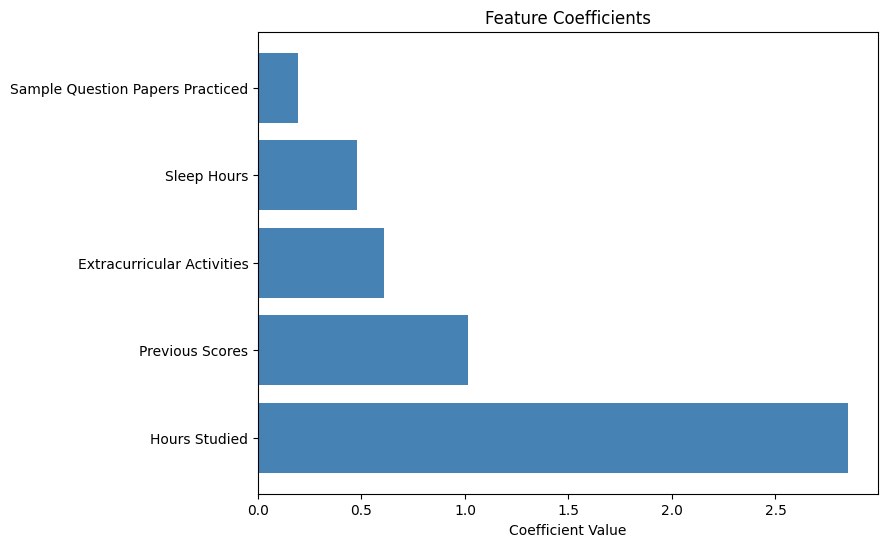

In [35]:
features = X.columns
coefficients = model.coef_

plt.figure(figsize=(8,6))

plt.barh(features, coefficients, color='steelblue')

plt.xlabel("Coefficient Value")
plt.title("Feature Coefficients")

plt.show()

## 8. Prediction on Unseen Data

To test how well the model generalizes, we randomly pick 25 rows
from the original dataset that were not used during training or testing.

We then:
- Predict the score for each of these 25 students
- Compare predicted scores with actual scores
- Calculate the difference to see how close the model is

This is a real world simulation of the model being used on new students.

In [37]:
# Pick 25 random rows from the original dataset
unseen_data = df.sample(n=25, random_state=10).reset_index(drop=True)

# Separate features and actual output
X_unseen = unseen_data[['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
                          'Sleep Hours', 'Sample Question Papers Practiced']]
y_actual = unseen_data['Performance Index'].reset_index(drop=True)

# Predict
y_unseen_pred = model.predict(X_unseen)

# Compare actual vs predicted
comparison = pd.DataFrame({
    'Actual Score'   : y_actual,
    'Predicted Score': y_unseen_pred.round(2),
    'Difference'     : (y_actual - y_unseen_pred).round(2)
})

print(comparison.to_string(index=True))

    Actual Score  Predicted Score  Difference
0           38.0            41.49       -3.49
1           27.0            26.85        0.15
2           30.0            34.30       -4.30
3           49.0            48.28        0.72
4           39.0            39.58       -0.58
5           52.0            51.15        0.85
6           21.0            18.84        2.16
7           52.0            52.94       -0.94
8           53.0            53.80       -0.80
9           40.0            42.08       -2.08
10          21.0            21.20       -0.20
11          37.0            33.85        3.15
12          45.0            41.00        4.00
13          73.0            68.27        4.73
14          67.0            67.34       -0.34
15          69.0            64.27        4.73
16          40.0            39.06        0.94
17          69.0            67.42        1.58
18          26.0            26.62       -0.62
19          70.0            68.82        1.18
20          82.0            81.83 

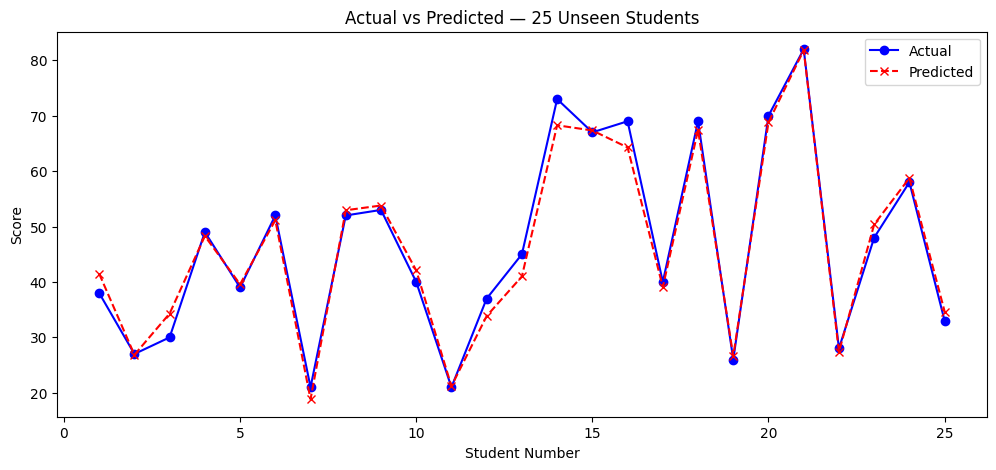

In [38]:
x_axis = range(1, 26)

plt.figure(figsize=(12, 5))

plt.plot(x_axis, y_actual, color='blue', marker='o', label='Actual')
plt.plot(x_axis, y_unseen_pred, color='red', marker='x', linestyle='--', label='Predicted')

plt.xlabel("Student Number")
plt.ylabel("Score")
plt.title("Actual vs Predicted — 25 Unseen Students")
plt.legend()

plt.show()


In [39]:

# Save the trained model
joblib.dump(model, 'student_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [40]:
# pipeline
# Reload fresh raw data (Yes/No intact)
df_raw = pd.read_csv("Student_Performance.csv")

# Features and target
X_raw = df_raw[['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
                'Sleep Hours', 'Sample Question Papers Practiced']]
y_raw = df_raw['Performance Index']

# Split raw data
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# Numerical pipeline — impute missing values with mean
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

# Categorical pipeline — impute missing with most frequent then encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['No', 'Yes']]))
])

# Combine both pipelines using ColumnTransformer
numerical_cols   = ['Hours Studied', 'Previous Scores',
                    'Sleep Hours', 'Sample Question Papers Practiced']
categorical_cols = ['Extracurricular Activities']

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline,   numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# Build final pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        LinearRegression())
])

# Fit pipeline
pipeline.fit(X_train_raw, y_train_raw)

# Evaluate
y_pred_pipe = pipeline.predict(X_test_raw)

print("R² Score :", round(r2_score(y_test_raw, y_pred_pipe), 4))
print("MAE      :", round(mean_absolute_error(y_test_raw, y_pred_pipe), 4))
print("RMSE     :", round(np.sqrt(mean_squared_error(y_test_raw, y_pred_pipe)), 4))

# Save pipeline
joblib.dump(pipeline, 'student_model_pipe.pkl')
print("Pipeline saved!")

R² Score : 0.989
MAE      : 1.6111
RMSE     : 2.0206
Pipeline saved!


In [41]:
sample = pd.DataFrame({
    'Hours Studied'                    : [7],
    'Previous Scores'                  : [99],
    'Extracurricular Activities'        : ['Yes'],
    'Sleep Hours'                      : [9],
    'Sample Question Papers Practiced' : [1]
})

result = pipeline.predict(sample)
print("Predicted Score:", round(result[0], 2))

Predicted Score: 91.82


## 9. Conclusion

- We successfully built a Linear Regression model to predict student exam scores
- The model achieved an R² score of 0.989 which means it explains 98.9% of the variance
- Previous Scores was the most influential feature with a correlation of 0.92
- The model predictions on unseen data were consistently within ±2 marks
- The trained model was saved using joblib for use in the Streamlit app

This project demonstrates a complete end to end machine learning workflow
from data loading and preprocessing to model training, evaluation and deployment.